### Imports and Seeds

In [75]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

import kagglehub
from pathlib import Path
from PIL import Image


#### Constants

In [15]:
seeds = [1, 2, 3, 4, 5]
IMG_SIZE = 32 # Original size was 128; use smaller sizes to run faster

# Hyperparameters
fast_iter = 50
fast_tol = 0.01
slow_iter = 1000
slow_tol = 0.0001

#### Downloading dataset (Kaggle)

In [13]:
# Download the datasets
path = kagglehub.dataset_download("ishans24/brain-tumor-dataset") # Primary
path_abouali = kagglehub.dataset_download("mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images")

Using Colab cache for faster access to the 'brain-tumor-dataset' dataset.
Using Colab cache for faster access to the 'mri-brain-tumor-dataset-4-class-7023-images' dataset.


### Loading the data:
Main function: load_data(base_path)
\
Ishans24 dataset: Compilation of many brain tumor datasets (https://www.kaggle.com/datasets/ishans24/brain-tumor-dataset)
\
Abouali dataset: Unlike Ishans24, this dataset is already divided into train and test (https://www.kaggle.com/datasets/mohamadabouali1/
mri-brain-tumor-dataset-4-class-7023-images)

Additionally, Abouali's dataset has 3 "challenge" datasets where images are blurry, noisy, or contain patient motion artifacts.

In [3]:
def load_data(base_path):
    X = []
    y = []
    class_names = sorted(os.listdir(base_path))

    for label, cls in enumerate(class_names):
        class_path = os.path.join(base_path, cls)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

    return np.array(X), np.array(y), class_names

X, y, class_names = load_data(path) # X:(10560, IMG_SIZE, IMG_SIZE); Y:(10560,)

In [4]:
# Paths
train_path2 = os.path.join(path_abouali, "BT-MRI Dataset", "BT-MRI Dataset", "Training")
test_path2 = os.path.join(path_abouali, "BT-MRI Dataset", "BT-MRI Dataset", "Testing")

X_train2, Y_train2, class_names2 = load_data(train_path2)
X_test2, Y_test2, class_names3 = load_data(test_path2) #class_names 2 and 3 are the same, but are seperated anyways.

# Verification
print(f"X_train2 Shape: {X_train2.shape}")  # (5712, 64, 64)
print(f"X_test2 Shape: {X_test2.shape}")  # (1311, 64, 64)
print(f"Class Names: {class_names2}") # ['Glioma', 'Meningioma', 'No-Tumor', 'Pituitary']

X_train2 Shape: (5712, 32, 32)
X_test2 Shape: (1311, 32, 32)
Class Names: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']


#### Random Image Generation and Class Distribution
1) Compile in dataframe: create_dataset_df(raw_path)
2) Image generator: random_image(df)
3) Pie chart to view class distribution:

In [5]:
# Compile into DataFrame
def create_dataset_df(raw_path):
    base_path = Path(raw_path)

    file_data = []
    # Search for all images in all subdirectories
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)

                # 'category' is the name of the folder containing the image
                category = os.path.basename(root)

                # Logic for 'is_tumor' based on common folder names
                # It will be 'no' if the folder is 'no' or 'no_tumor', otherwise 'yes'
                is_tumor = 'no' if category.lower() in ['no', 'no_tumor'] else 'yes'

                # Extract image dimensions as features
                try:
                    with Image.open(full_path) as img:
                        width, height = img.size
                except:
                    width, height = (None, None)

                file_data.append({
                    'category': category,
                    'is_tumor': is_tumor,
                    'width': width,
                    'height': height,
                    'filename': file
                })

    return pd.DataFrame(file_data)


# Create the DataFrame
df = create_dataset_df(path)

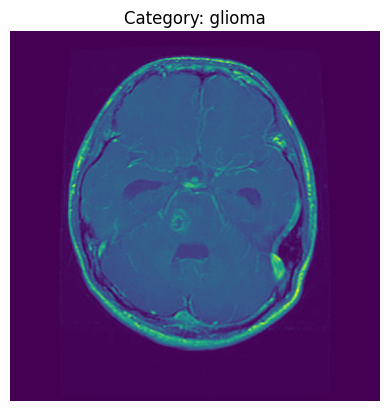

In [6]:
def random_image(df):
  number_of_tumors = len(df[df['is_tumor'] == 'yes'])
  tumor_samples = df[df['is_tumor'] == 'yes']
  random = np.random.randint(0, high=number_of_tumors, dtype=int)

  # Pick one random row
  sample = tumor_samples.sample().iloc[0]
  img_path = os.path.join(path, sample['category'], sample['filename'])

  img = Image.open(img_path)
  plt.imshow(img)
  plt.title(f"Category: {sample['category']}")
  plt.axis('off') # Hide the x/y axes
  plt.show()

random_image(df)

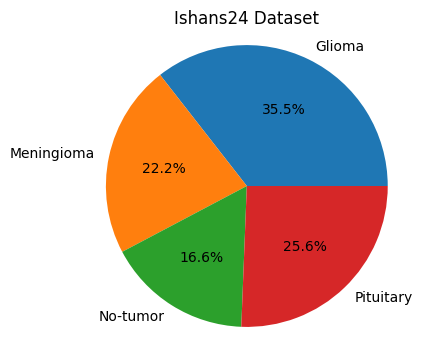

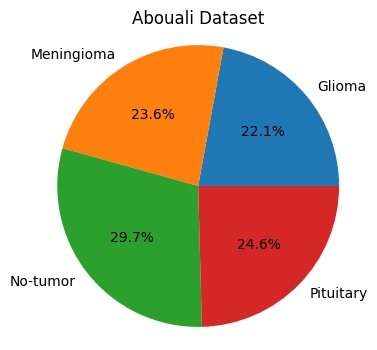

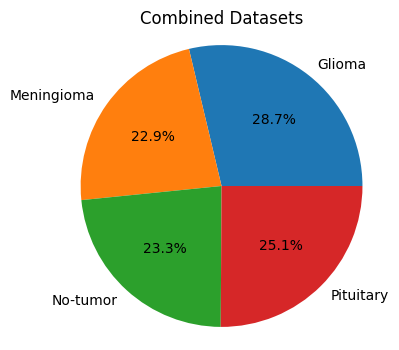

In [66]:
def plot_distribution(df, title):
    df = df.copy()

    category_map = {
        'no_tumor': 'no_tumor',
        'notumor': 'no_tumor',
        'no-tumor': 'no_tumor',

        'glioma': 'glioma',
        'glioma_tumor': 'glioma',

        'meningioma': 'meningioma',
        'meningioma_tumor': 'meningioma',

        'pituitary': 'pituitary',
        'pituitary_tumor': 'pituitary',
    }

    df['category'] = (
        df['category']
        .str.strip()
        .str.lower()
        .replace(category_map)
    )

    # fixed class order
    category_order = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

    category_counts = (
        df['category']
        .value_counts()
        .reindex(category_order, fill_value=0)
    )

    label_map = {
        'no_tumor': 'No-tumor',
        'glioma': 'Glioma',
        'meningioma': 'Meningioma',
        'pituitary': 'Pituitary',
    }

    category_labels = [label_map.get(cat, cat) for cat in category_counts.index]

    plt.figure(figsize=(4, 4))
    plt.title(title)
    plt.pie(category_counts, labels=category_labels, autopct='%1.1f%%')
    plt.axis('equal')
    plt.show()

plot_distribution(df, 'Ishans24 Dataset')
df2 = create_dataset_df(path_abouali)
plot_distribution(df2, 'Abouali Dataset')
df_combined = pd.concat([df, df2], ignore_index=True)
plot_distribution(df_combined, 'Combined Datasets')

#### Data processing:
1) Flatten and Normalise
2) Split into training and test sets (if applicable)

In [8]:
# Flatten + Normalize
def flatten_and_normalize(X):
  X_flatten = X.reshape(len(X), -1)
  X_normalize = X_flatten / 255.0 #(10560, IMG_SIZE*IMG_SIZE)
  return(X_normalize)
X_normalize = flatten_and_normalize(X)

#### Baseline SVM on Ishans24

In [78]:
# For storing results across seeds
baseline_scores = []
cms_ishans = []
# MULTI-SEED EXPERIMENT
for seed in seeds:
    print(f"\n===== Running seed {seed} =====")
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_normalize, y, test_size=0.2, random_state=seed
    )

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # SVM training
    svm_baseline = LinearSVC(dual=False, max_iter=fast_iter, tol=fast_tol)
    svm_baseline.fit(X_train, y_train)

    # Accuracy
    acc_baseline = svm_baseline.score(X_test, y_test)
    baseline_scores.append(acc_baseline)

    # Confusion Matrix
    predictions_ishans24 = svm_baseline.predict(X_test)
    cm_ishans24 = confusion_matrix(predictions_ishans24, y_test)
    cms_ishans.append(cm_ishans24)

    print(f"Baseline Accuracy: {acc_baseline:.4f}")

# Compute mean/std
def mean_std(arr):
    return np.mean(arr), np.std(arr)

baseline_mean, baseline_std = mean_std(baseline_scores)


===== Running seed 1 =====
Baseline Accuracy: 0.8466

===== Running seed 2 =====
Baseline Accuracy: 0.8674

===== Running seed 3 =====
Baseline Accuracy: 0.8546

===== Running seed 4 =====
Baseline Accuracy: 0.8366

===== Running seed 5 =====
Baseline Accuracy: 0.8518


#### Baseline SVM on Abouali

In [81]:
baseline_scores_abouali = []
seeds_ali = [1]

# One seed only (The data was already split)
# Can technically concatenate and then split if desired
for seed in seeds_ali:
    print(f"\n===== Running seed {seed} =====")
    X_train2_N = flatten_and_normalize(X_train2)
    X_test2_N = flatten_and_normalize(X_test2)

    # Scaling
    scaler = StandardScaler()
    X_train2_NS = scaler.fit_transform(X_train2_N)
    X_test2_NS = scaler.transform(X_test2_N)

    # SVM training
    svm_baseline = LinearSVC(dual=False, max_iter=fast_iter, tol=fast_tol)
    svm_baseline.fit(X_train2_NS, Y_train2)

    # Accuracy
    acc_baseline = svm_baseline.score(X_test2_N, Y_test2)
    baseline_scores_abouali.append(acc_baseline)

    # Confusion Matrix
    predictions_abouali = svm_baseline.predict(X_test2_N)
    cm_abouali = confusion_matrix(predictions_abouali, Y_test2)

    print(f"Baseline Accuracy (Abouali): {acc_baseline:.4f}")

# Compute mean/std
def mean_std(arr):
    return np.mean(arr), np.std(arr)

baseline_mean_ali, baseline_std_ali = mean_std(baseline_scores_abouali)


===== Running seed 1 =====
Baseline Accuracy (Abouali): 0.3143


### Combining the 2 datasets

In [ ]:
# c -> combined
# X train
X_train_c = np.concatenate((X_train, X_train2_NS), axis=0)
# Y Train
Y_train_c = np.concatenate((y_train, Y_train2), axis=0)
# X Test
X_test_c = np.concatenate((X_test, X_test2_NS), axis=0)
# Y Test
Y_test_c = np.concatenate((y_test, Y_test2), axis=0)

# print(X_train_c.shape)
# print(Y_train_c.shape)
# print(X_test_c.shape)
# print(Y_test_c.shape)

# Combining the two into pre-split form allows for the usage of multiple seeds, acquiring mean and std.
# PS -> pre-split

X_PS = np.concatenate ((X_train_c, X_test_c), axis=0)
Y_PS = np.concatenate ((Y_train_c, Y_test_c), axis=0)
X_PS.shape, Y_PS.shape # Shape:((17583, 1024), (17583,))

((17583, 1024), (17583,))

In [ ]:
# For storing results across seeds
baseline_scores_c = []
seeds = [1,2,3,4,5]
cms_combined = []
# MULTI-SEED EXPERIMENT
for seed in seeds:
    print(f"\n===== Running seed {seed} =====")
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_PS, Y_PS, test_size=0.2, random_state=seed)

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # SVM training
    svm_baseline_merged = LinearSVC(dual=False, max_iter=fast_iter, tol=fast_tol)
    svm_baseline_merged.fit(X_train, y_train)

    # Accuracy
    acc_baseline_c = svm_baseline_merged.score(X_test, y_test)
    baseline_scores_c.append(acc_baseline_c)

    # Confusion Matrix
    predictions_combined = svm_baseline.predict(X_test)
    cm_merged = confusion_matrix(predictions_combined, y_test)
    cms_combined.append(cm_merged)

    print(f"Baseline Accuracy: {acc_baseline_c:.4f}")

# Compute mean/std
def mean_std(arr):
    return np.mean(arr), np.std(arr)

baseline_mean_c, baseline_std_c = mean_std(baseline_scores_c)


===== Running seed 1 =====
Baseline Accuracy: 0.8868

===== Running seed 2 =====
Baseline Accuracy: 0.8803

===== Running seed 3 =====
Baseline Accuracy: 0.8897

===== Running seed 4 =====
Baseline Accuracy: 0.8888

===== Running seed 5 =====
Baseline Accuracy: 0.8914


In [59]:
import joblib

# save
joblib.dump(svm_baseline_merged, "svm_final.pkl")

# load
svm_final = joblib.load("svm_final.pkl")

#### Results: Plots

In [54]:
def plot_results(means, stds, methods, ylabel, title):
    # Note: If there is only one result for mean and std, they must be inputted as [mean] and [std] to avoid an error from the enumerate.
    # Create the bars
    bars = plt.bar(methods, means, yerr=stds, capsize=7)

    for i, v in enumerate(means):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold', fontsize=10)

    # Formatting
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

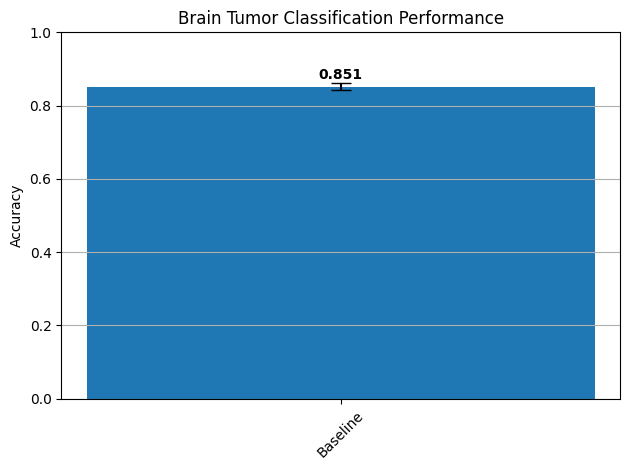

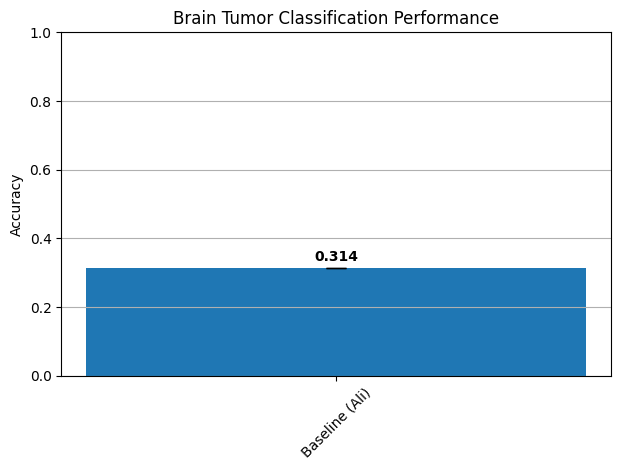

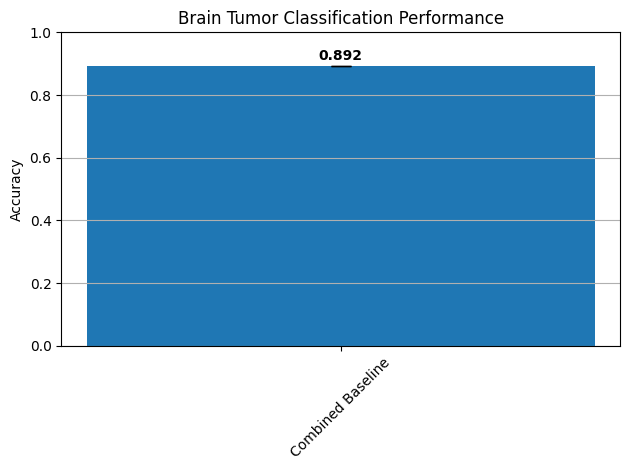

In [49]:
plot_results(
    [baseline_mean, baseline_mean_ali, baseline_mean_c],
    [baseline_std, baseline_std_ali, baseline_std_c],
    ['Baseline', 'Baseline (Ali)', 'Combined Baseline'],
    'Accuracy',
    'Brain Tumor Classification Performance'
)

#### Confusion Matrix

In [111]:
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(5, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [118]:
cms_ishans_c = cms_ishans[0] + cms_ishans[1] + cms_ishans[2] + cms_ishans[3] + cms_ishans[4]
cms_combined_c = cms_combined[0] + cms_combined[1] + cms_combined[2] + cms_combined[3] + cms_combined[4]

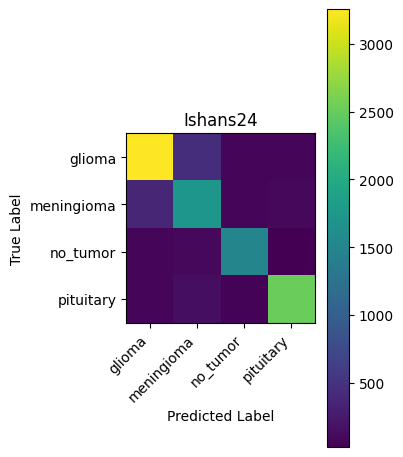

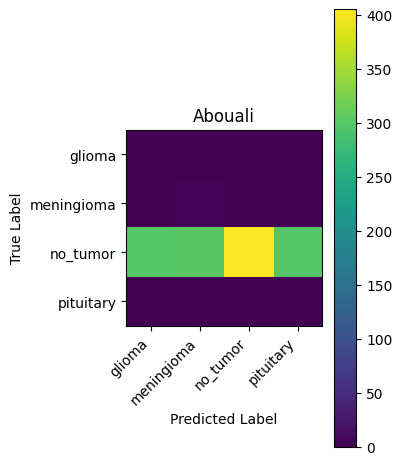

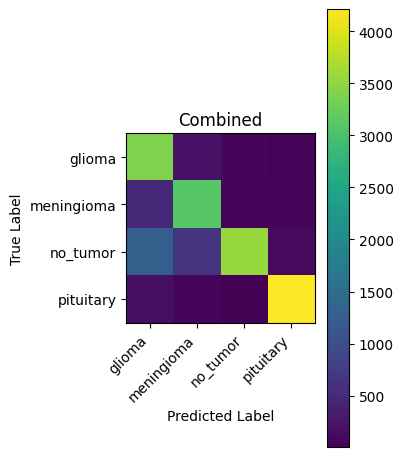

In [119]:
plot_confusion_matrix(cms_ishans_c, class_names, 'Ishans24')
plot_confusion_matrix(cm_abouali, class_names, 'Abouali')
plot_confusion_matrix(cms_combined_c, class_names, 'Combined')